## 1 Objective

1. Build decision tree classifier using **scikit-learn: `DecisionTreeClassifier`**.
2. Visualize decision tree using **scikit-learn: `plot_tree`**.

## 2 Setup

### 2.1 Import and configure required libraries

In [1]:
# General imports
import math

# Data manipulation libraries
import numpy as np
import pandas as pd

# Data visualization libraries
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import prettytable
from prettytable import PrettyTable

# Data modeling libraries.
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Library versions.
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("PrettyTable version:", prettytable.__version__)
print("Sklearn version:", sklearn.__version__)

NumPy version: 2.5.2
Pandas version: 3.0.5
PrettyTable version: 3.18.0
Sklearn version: 1.9.0


In [2]:
# Configure Pandas.
# Set display width to maximum 130 characters in the output, post which it will continue in next line.
pd.options.display.width = 130

### 2.2 Load data-points from the `.csv` file

In [3]:
wthr_df = pd.read_csv("data/weather_forecast.csv")
wthr_df.head(14)

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


## 3 Data Analysis

In [4]:
rows, cols = wthr_df.shape
print(f"Dataset contains {rows} rows and {cols} columns.")

Dataset contains 14 rows and 5 columns.


### 3.1 Metadata

In [5]:
wthr_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Outlook      14 non-null     str  
 1   Temperature  14 non-null     str  
 2   Humidity     14 non-null     str  
 3   Windy        14 non-null     str  
 4   Play         14 non-null     str  
dtypes: str(5)
memory usage: 692.0 bytes


#### Observations

1. Dataset contains **14 rows and 5 columns**.
2. All five columns in 14 rows have `non-null` values. **No missing data**.
3. All the columns contain data in **string data-type**.
4. All the columns are **categorical features**.

### 3.2 Features and Class-label

#### Distinct values in features

In [6]:
table = PrettyTable(["Features", "Distinct Values", "Count"], align="l")

for feature in wthr_df.columns[0:-1]:
    unq_vals = wthr_df[feature].unique().tolist()
    table.add_row([feature, ", ".join(unq_vals), len(unq_vals)])

print(table)

+-------------+-----------------------+-------+
| Features    | Distinct Values       | Count |
+-------------+-----------------------+-------+
| Outlook     | Sunny, Overcast, Rain | 3     |
| Temperature | Hot, Mild, Cool       | 3     |
| Humidity    | High, Normal          | 2     |
| Windy       | Weak, Strong          | 2     |
+-------------+-----------------------+-------+


#### Class label

In [7]:
wthr_df["Play"].value_counts()

Play
Yes    9
No     5
Name: count, dtype: int64

#### Observations

1. Dataset is **slightly imbalanced**.
2. Dataset contains **64% positive data-points** i.e., Play = "Yes". Positive data-points are **Majority class**.
3. Dataset contains **36% negative data-points** i.e., Play = "No". Negative data-points are **Minority class**.

### 3.3 How Imbalanced dataset affects Decision Tree?

Imbalanced dataset impacts Entropy/MSE calculation.

#### Solution

Solution to above problem is either **Up-sampling** or **Down-sampling**. In this case Up-sampling is better than Down-sampling since the dataset is too small.

### 3.4 Up-sampling the Minority class

Up-sampling dataset by duplicating last four rows in the dataset.

In [8]:
# Filter to fetch all minority class values.
fltr = wthr_df["Play"] == "No"

# Apply filter and slice out last four rows.
last_four_rows = wthr_df.loc[fltr][-4:]

# Append last four rows of original DataFrame into a new DataFrame.
wthr_dfb = pd.concat([wthr_df, last_four_rows], ignore_index=True)

# Sort by `Play` column to check the concatenation.
wthr_dfb.sort_values(by=["Play"], ascending=False)

,Outlook,Temperature,Humidity,Windy,Play
9,Rain,Mild,Normal,Weak,Yes
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
6,Overcast,Cool,Normal,Strong,Yes
8,Sunny,Cool,Normal,Weak,Yes
10,Sunny,Mild,Normal,Strong,Yes
11,Overcast,Mild,High,Strong,Yes
12,Overcast,Hot,Normal,Weak,Yes
13,Rain,Mild,High,Strong,No


In [9]:
# Verify if dataset is balanced.
wthr_dfb["Play"].value_counts()

Play
No     9
Yes    9
Name: count, dtype: int64

Now the dataset is balanced!

## 4 scikit-learn: `DecisionTreeClassifier`

Segregate attributes in the dataset into features and class-label respectively into `X_train` and `y_train`.

In [10]:
X_train = wthr_dfb[["Outlook", "Temperature", "Humidity", "Windy"]]
y_train = wthr_dfb["Play"]

Converting categorical data columns into numerical data.

In [11]:
le = LabelEncoder()

X_train = X_train.apply(le.fit_transform)
y_train = le.fit_transform(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (18, 4)
y_train shape: (18,)


Train a decision tree classifier.

In [12]:
clf = DecisionTreeClassifier(max_leaf_nodes=5, random_state=0)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

## 5 scikit-learn: `plot_tree`

### 5.1 Plot Decision Tree

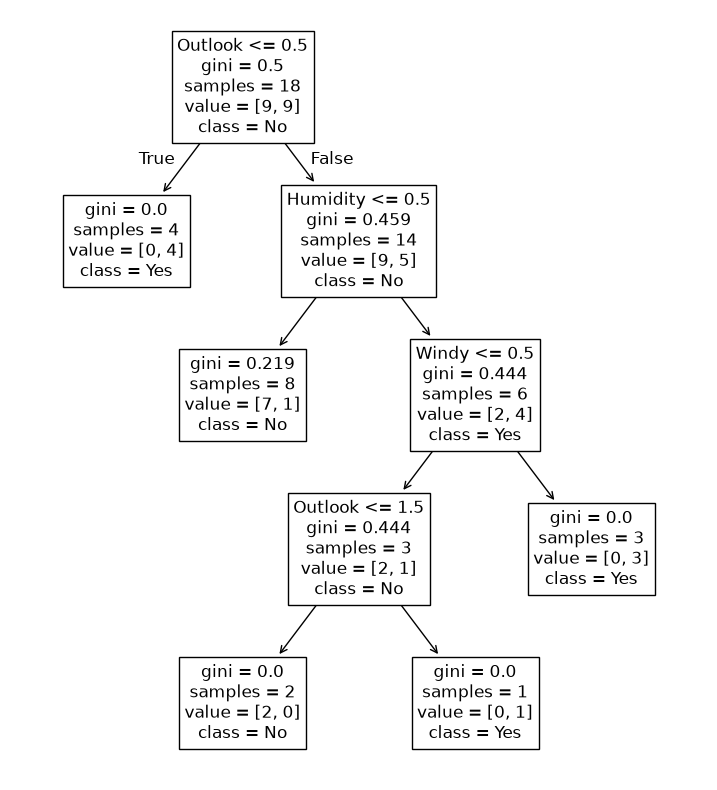

In [18]:
fig = plt.figure(figsize=(9, 10))  # Figsize: Width, Height
tree.plot_tree(clf, feature_names=X_train.columns.tolist(), class_names=["No", "Yes"], fontsize=12)
plt.show()

### 5.2 Feature Importance

In [29]:
fi_df = pd.DataFrame(
    {
        "Feature": clf.feature_names_in_,
        "Importance": clf.feature_importances_.round(2),
    }
).sort_values(by="Importance", ascending=False)
fi_df

,Feature,Importance
0,Outlook,0.54
2,Humidity,0.28
3,Windy,0.18
1,Temperature,0.00


> Note: Higher the value better